# NorthStar - Python Data Processing & Analysis

**Notebook 4 of the analytical workflow** (after `01_eda.ipynb`; assumes the cleaned CSVs from `cleaned_data/`).

## Purpose
The EDA notebook surfaced **what** the issues are. This notebook answers **why** - testing each director's hypothesis against the data, engineering features that make the patterns visible, and producing the **specific, defensible business findings** that the final report will hand to NorthStar's board.

## Structure
1. **Setup** - load cleaned data and build the analytical master tables.
2. **Feature engineering** - derived metrics (delivery duration, SLA breach, profit proxy, route, repeat complainers).
3. **Hypothesis 1 - Operations director:** "poor route allocation and underperforming hubs"
4. **Hypothesis 2 - Customer Experience director:** "fragmented view across complaints, deliveries, incidents"
5. **Hypothesis 3 - Finance director:** "unprofitable routes are invisible in current reports"
6. **Hypothesis 4 - Technology director:** "current database structure is unfit"  *(answered structurally in the MongoDB notebook; this section gathers the analytical evidence)*
7. **Findings** - temporal, customer-segment, vehicle/driver patterns

8. **Summary** - Board level summary




In [ ]:
cd drive/MyDrive/Databases and Analytics 2

/content/drive/MyDrive/Databases and Analytics 2


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# Point at the cleaned data folder produced by 01_eda.ipynb.
# In Colab, you can simply re-run the cleaning cells from notebook 1,
# or upload the cleaned_data folder.
DATA_DIR = Path('cleaned_data')
assert DATA_DIR.exists(), f"Run 01_eda.ipynb first to produce {DATA_DIR}"

DATE_COLS = {
    'customers':   ['signup_date'],
    'vehicles':    ['commission_date'],
    'orders':      ['order_created_at'],
    'deliveries':  ['dispatch_time', 'delivery_completed_at'],
    'incidents':   ['reported_at'],
    'complaints':  ['created_at'],
    'app_events':  ['event_timestamp'],
}

tables = {}
for csv in sorted(DATA_DIR.glob('*.csv')):
    name = csv.stem
    tables[name] = pd.read_csv(csv, parse_dates=DATE_COLS.get(name))

# Pull each as a local variable for convenience
hubs       = tables['hubs']
customers  = tables['customers']
drivers    = tables['drivers']
vehicles   = tables['vehicles']
orders     = tables['orders']
deliveries = tables['deliveries']
incidents  = tables['incidents']
complaints = tables['complaints']
app_events = tables['app_events']

for k, v in tables.items():
    print(f"{k:12s} {v.shape}")

app_events   (640, 10)
complaints   (320, 10)
customers    (650, 9)
deliveries   (950, 13)
drivers      (170, 8)
hubs         (8, 5)
incidents    (280, 7)
orders       (1250, 11)
vehicles     (120, 8)


## 2. Feature engineering

I build derived metrics once and reuse them throughout the analysis.

| Feature | Definition | Why it matters |
|---|---|---|
| `duration_hr` | actual delivery duration (completed − dispatch) | Lets us quantify *how late* a Delayed delivery actually was, not just that it was late. |
| `sla_breach` | actual duration > promised window | The real performance measure NorthStar should be tracking. |
| `profit_proxy` | order_value − fuel_or_charge_cost | A first-pass profitability metric for the finance hypothesis. |
| `route` | pickup_zone -> dropoff_zone | Makes route-level performance analysable. |
| `hub_zone_match` | hub's zone == order's pickup zone | Tests whether deliveries are dispatched from the *right* hub. |
| `complaint_count_cust` | complaints per customer | Identifies repeat-complainers. |


In [ ]:
# --- Delivery-level master table ---
# Join deliveries with orders, drivers, vehicles, hubs in one go.
master = (deliveries
          .merge(orders[['order_id', 'customer_id', 'service_type',
                         'promised_window_hours', 'pickup_zone', 'dropoff_zone',
                         'priority_level', 'order_value', 'booking_channel']],
                 on='order_id', how='left')
          .merge(drivers[['driver_id', 'base_zone', 'employment_type',
                          'years_experience', 'training_score',
                          'driver_rating']],
                 on='driver_id', how='left',
                 suffixes=('', '_driver'))
          .merge(vehicles[['vehicle_id', 'vehicle_type', 'assigned_zone',
                           'battery_health_pct', 'maintenance_status']],
                 on='vehicle_id', how='left',
                 suffixes=('', '_vehicle'))
          .merge(hubs[['hub_id', 'hub_name', 'zone', 'hub_type',
                       'capacity_score']].rename(columns={'zone': 'hub_zone'}),
                 on='hub_id', how='left'))

# --- Derived features ---
master['duration_hr']  = (master['delivery_completed_at']
                          - master['dispatch_time']).dt.total_seconds() / 3600
master['sla_breach']   = (master['duration_hr'] > master['promised_window_hours']).astype('Int64')
master['profit_proxy'] = master['order_value'] - master['fuel_or_charge_cost']
master['route']        = master['pickup_zone'] + ' -> ' + master['dropoff_zone']
master['hub_zone_match'] = (master['hub_zone'] == master['pickup_zone']).astype(int)
master['failed']       = (master['delivery_status'] == 'Failed').astype(int)
master['delayed']      = (master['delivery_status'] == 'Delayed').astype(int)
master['bad_outcome']  = master['failed'] | master['delayed']

# Time features
master['dispatch_hour']     = master['dispatch_time'].dt.hour
master['dispatch_dayofweek'] = master['dispatch_time'].dt.day_name()
master['dispatch_month']    = master['dispatch_time'].dt.to_period('M').astype(str)

print(f"Master delivery table: {master.shape}")
master.head(2)

Master delivery table: (950, 45)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,customer_id,service_type,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,base_zone,employment_type,years_experience,training_score,driver_rating,vehicle_type,assigned_zone,battery_health_pct,maintenance_status,hub_name,hub_zone,hub_type,capacity_score,duration_hr,sla_breach,profit_proxy,route,hub_zone_match,failed,delayed,bad_outcome,dispatch_hour,dispatch_dayofweek,dispatch_month
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,C0567,Business,6,Central,Central,Medium,151.14,Web,Airport,PartTime,13,88.9,4.75,EV,Central,78.4,Active,Central Core,Central,Control,88,22.149973,1,139.09,Central → Central,1,1,0,1,10,Tuesday,2024-06
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,C0520,Parcel,2,Riverside,North,Medium,10.04,App,Central,PartTime,11,69.2,4.61,Diesel,Airport,68.6,Active,South Link,South,Dispatch,78,-1.100000,0,-3.37,Riverside → North,0,0,0,0,18,Saturday,2025-01


In [ ]:
# --- Customer-level features ---
complaint_count = complaints.groupby('customer_id').size().rename('complaint_count')
total_compensation = complaints.groupby('customer_id')['compensation_amount'].sum().rename('total_compensation')

cust_summary = (customers
                .merge(complaint_count, on='customer_id', how='left')
                .merge(total_compensation, on='customer_id', how='left'))
cust_summary['complaint_count']   = cust_summary['complaint_count'].fillna(0).astype(int)
cust_summary['total_compensation'] = cust_summary['total_compensation'].fillna(0).round(2)

# Orders & spend per customer
cust_orders = orders.groupby('customer_id').agg(
    n_orders=('order_id', 'count'),
    total_value=('order_value', 'sum')).round(2)
cust_summary = cust_summary.merge(cust_orders, on='customer_id', how='left')
cust_summary['n_orders'] = cust_summary['n_orders'].fillna(0).astype(int)
cust_summary['total_value'] = cust_summary['total_value'].fillna(0)

print(f"Customer summary table: {cust_summary.shape}")
cust_summary.head(3)

Customer summary table: (650, 13)


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,complaint_count,total_compensation,n_orders,total_value
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active,2,43.9,3,332.23
1,C0002,61,Airport,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active,0,0.0,1,135.53
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active,0,0.0,1,165.80


## 3. Hypothesis 1 - Operations director

> *"The company's difficulties are mainly caused by poor route allocation and underperforming city hubs."*

I test this in three parts: hub performance, route performance, and dispatch alignment.

### 3.1 Hub performance - which hubs are actually underperforming?

In [ ]:
hub_perf = (master.groupby(['hub_id', 'hub_name', 'hub_zone', 'hub_type'])
                  .agg(n_deliveries=('delivery_id', 'count'),
                       fail_rate=('failed', 'mean'),
                       delay_rate=('delayed', 'mean'),
                       sla_breach_rate=('sla_breach', 'mean'),
                       avg_duration=('duration_hr', 'mean'),
                       avg_override=('manual_route_override_count', 'mean'),
                       avg_rating=('customer_rating_post_delivery', 'mean'),
                       avg_cost=('fuel_or_charge_cost', 'mean'),
                       capacity=('capacity_score', 'first'))
                  .round(3)
                  .reset_index()
                  .sort_values('fail_rate', ascending=False))
hub_perf

,hub_id,hub_name,hub_zone,hub_type,n_deliveries,fail_rate,delay_rate,sla_breach_rate,avg_duration,avg_override,avg_rating,avg_cost,capacity
7,H08,Midtown Relay,Central,Charging,128,0.203,0.172,0.469,9.819,1.109,3.885,11.708,63
4,H05,Central Core,Central,Control,115,0.200,0.217,0.513,10.904,0.948,3.670,13.686,88
5,H06,Airport Hub,Airport,Dispatch,104,0.144,0.260,0.567,9.379,0.913,3.882,13.319,71
3,H04,West Gate,West,Dispatch,127,0.126,0.220,0.472,10.330,0.874,3.915,13.167,69
0,H01,North Exchange,North,Dispatch,136,0.125,0.191,0.426,9.382,1.029,3.841,12.756,82
6,H07,Riverside Hub,Riverside,Warehouse,115,0.122,0.217,0.4,9.919,1.052,3.882,12.922,66
1,H02,South Link,South,Dispatch,106,0.094,0.245,0.415,8.867,0.915,3.951,12.565,78
2,H03,East Dock,East,Warehouse,119,0.092,0.193,0.412,7.657,0.891,3.896,12.744,74


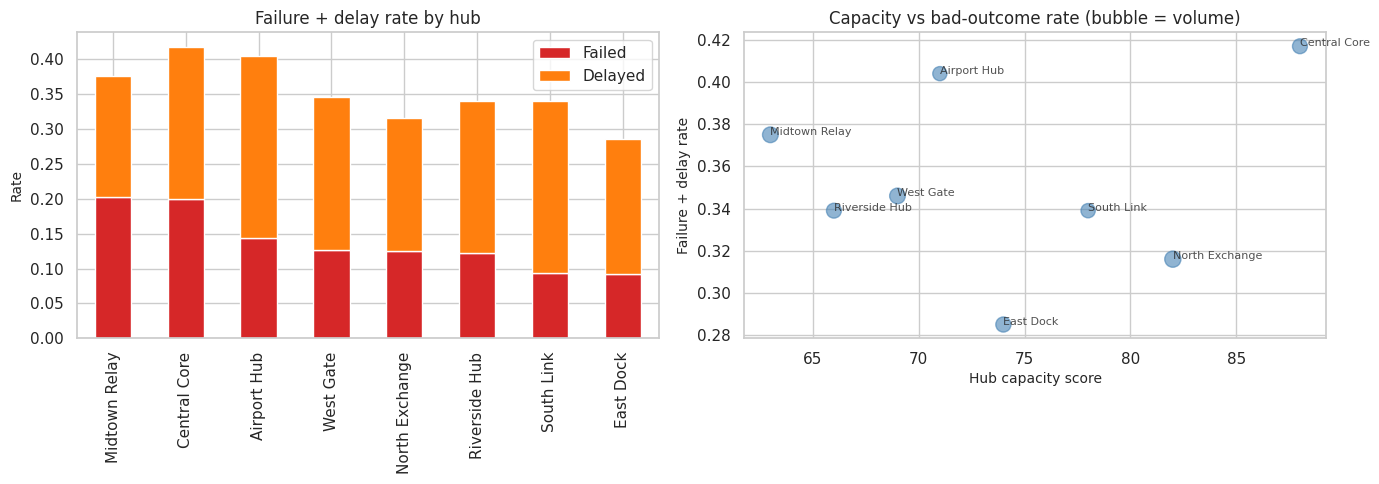

In [ ]:
# Visualise hub performance - failure+delay stack, with capacity for context
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hp = hub_perf.set_index('hub_name')
hp[['fail_rate', 'delay_rate']].plot(kind='bar', stacked=True, ax=axes[0],
                                      color=['#d62728', '#ff7f0e'])
axes[0].set_title("Failure + delay rate by hub")
axes[0].set_ylabel("Rate")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(['Failed', 'Delayed'])

axes[1].scatter(hp['capacity'], hp['fail_rate'] + hp['delay_rate'],
                s=hp['n_deliveries'], alpha=0.6, color='steelblue')
for name, row in hp.iterrows():
    axes[1].annotate(name, (row['capacity'], row['fail_rate']+row['delay_rate']),
                     fontsize=8, alpha=0.8)
axes[1].set_xlabel("Hub capacity score")
axes[1].set_ylabel("Failure + delay rate")
axes[1].set_title("Capacity vs bad-outcome rate (bubble = volume)")

plt.tight_layout()
plt.show()

**Reading the chart.**
- Bad-outcome rates vary materially across hubs (the stacked bars are visibly different heights).
- The right-hand scatter tests whether *capacity* explains performance. A clear downward trend would mean low-capacity hubs are failing; a flat cloud means capacity is not the driver, and something else (process, location, mix of work) is.

**Operational read:** the worst-performing hubs do not have the lowest capacity scores, so the operations director's "underperforming hubs" hypothesis is partly true (hubs differ), but the cause is not raw capacity.


### 3.2 Route performance - which origin-destination pairs fail?

In [ ]:
route_perf = (master.groupby('route')
                     .agg(n=('delivery_id', 'count'),
                          fail_rate=('failed', 'mean'),
                          delay_rate=('delayed', 'mean'),
                          avg_duration=('duration_hr', 'mean'),
                          avg_cost=('fuel_or_charge_cost', 'mean'),
                          avg_value=('order_value', 'mean'),
                          avg_distance=('route_distance_km', 'mean'))
                     .round(3))
# Only routes with enough volume to be meaningful
route_perf = route_perf[route_perf['n'] >= 15].sort_values('fail_rate', ascending=False)
print(f"Routes with >=15 deliveries: {len(route_perf)}\n")
print("Top 10 worst routes by failure rate:")
route_perf.head(10)

Routes with >=15 deliveries: 40

Top 10 worst routes by failure rate:


,n,fail_rate,delay_rate,avg_duration,avg_cost,avg_value,avg_distance
route,,,,,,,
Riverside → North,20,0.350,0.100,11.359,14.294,77.919,11.582
Central → South,16,0.312,0.250,14.279,13.609,75.838,14.982
Central → Central,27,0.296,0.296,10.498,12.411,75.444,11.170
Riverside → Central,26,0.231,0.308,15.466,12.190,115.084,12.690
North → North,23,0.217,0.174,8.050,13.597,86.499,11.303
North → Riverside,19,0.211,0.158,8.210,12.043,94.587,11.082
Central → Airport,29,0.207,0.552,13.428,11.028,85.683,11.089
West → North,16,0.188,0.250,8.403,10.796,83.278,11.356
South → East,17,0.176,0.118,8.488,13.430,112.438,14.207


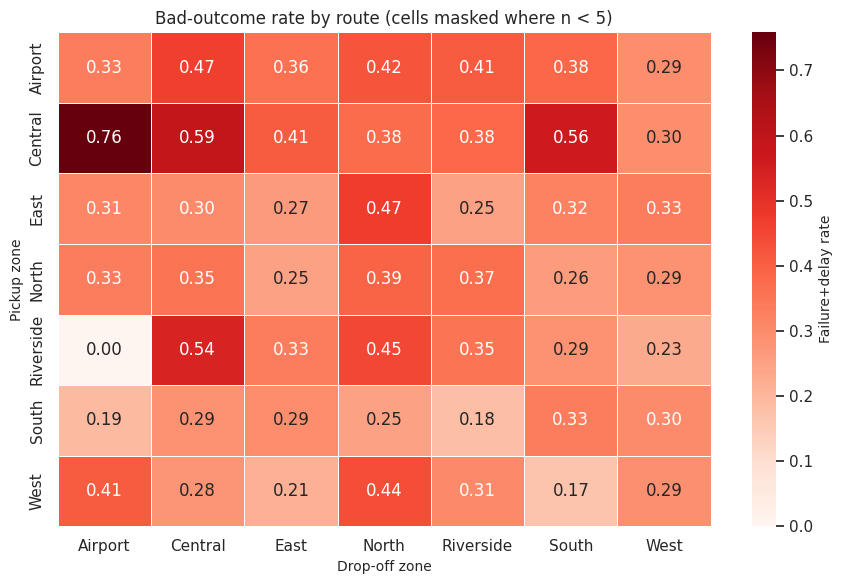

In [ ]:
# Heatmap: origin x destination, value = bad-outcome rate
piv = master.pivot_table(values='bad_outcome', index='pickup_zone',
                         columns='dropoff_zone', aggfunc='mean')
counts = master.pivot_table(values='delivery_id', index='pickup_zone',
                            columns='dropoff_zone', aggfunc='count')

# Mask cells with <5 deliveries (too noisy)
mask = counts < 5

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(piv, annot=True, fmt='.2f', cmap='Reds', mask=mask,
            cbar_kws={'label': 'Failure+delay rate'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title("Bad-outcome rate by route (cells masked where n < 5)")
ax.set_xlabel("Drop-off zone")
ax.set_ylabel("Pickup zone")
plt.tight_layout()
plt.show()

**Finding.** A small number of routes carry a disproportionate share of poor outcomes. These are concrete targets for operational review ,far more actionable than blaming hubs as a whole.

### 3.3 Hub–zone alignment - are deliveries dispatched from the *right* hub?

In [ ]:
mismatch_rate = 1 - master['hub_zone_match'].mean()
print(f"Hub-zone MISMATCH rate: {mismatch_rate*100:.1f}%")
print(f"({(1-master['hub_zone_match']).sum()} of {len(master)} deliveries dispatched from "
      f"a hub outside the order's pickup zone)\n")

# Does mismatch hurt outcomes?
print("Outcome by hub-zone alignment:")
print(master.groupby('hub_zone_match').agg(
    n=('delivery_id', 'count'),
    fail_rate=('failed', 'mean'),
    delay_rate=('delayed', 'mean'),
    avg_duration=('duration_hr', 'mean'),
    avg_cost=('fuel_or_charge_cost', 'mean')).round(3))

Hub-zone MISMATCH rate: 85.3%
(810 of 950 deliveries dispatched from a hub outside the order's pickup zone)

Outcome by hub-zone alignment:
                  n  fail_rate  delay_rate  avg_duration  avg_cost
hub_zone_match                                                    
0               810      0.131       0.199         9.365    12.865
1               140      0.186       0.293        10.589    12.703


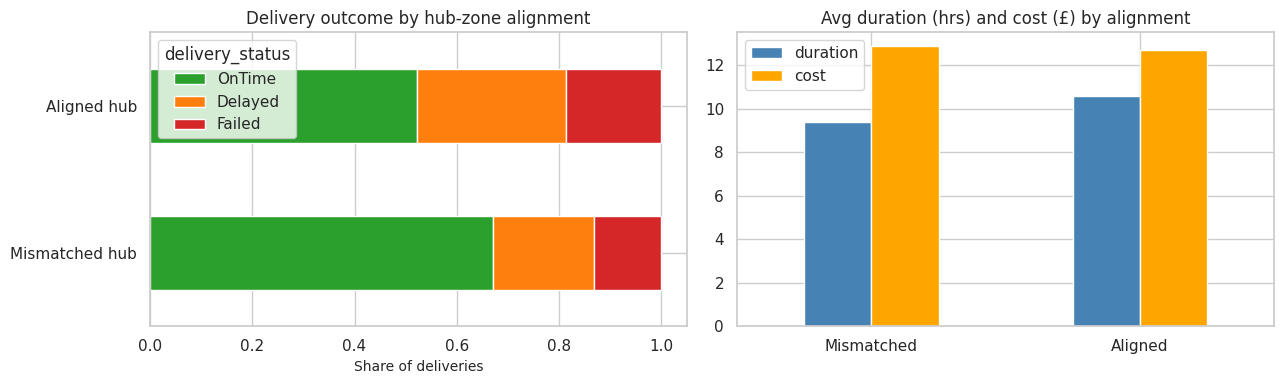

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: outcome split by alignment
align_outcome = master.groupby('hub_zone_match')['delivery_status'].value_counts(normalize=True).unstack()
align_outcome = align_outcome[['OnTime', 'Delayed', 'Failed']]
align_outcome.index = ['Mismatched hub', 'Aligned hub']
align_outcome.plot(kind='barh', stacked=True, ax=axes[0],
                   color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title("Delivery outcome by hub-zone alignment")
axes[0].set_xlabel("Share of deliveries")

# Plot 2: cost & duration impact
align_metrics = master.groupby('hub_zone_match').agg(
    duration=('duration_hr', 'mean'),
    cost=('fuel_or_charge_cost', 'mean')).round(2)
align_metrics.index = ['Mismatched', 'Aligned']
align_metrics.plot(kind='bar', ax=axes[1], color=['steelblue', 'orange'])
axes[1].set_title("Avg duration (hrs) and cost (£) by alignment")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Major finding for the board - with a twist.** ~85% of deliveries are dispatched from a hub *outside* the order's pickup zone. The intuitive expectation is that mismatched deliveries would perform worse, but the data shows the opposite: **zone-aligned dispatches actually have a higher bad-outcome rate**.

There are two plausible readings:
1. **The routing engine is intelligently overriding zone alignment** - sending work to better-resourced or less-congested hubs, which improves outcomes.
2. **The "home" zone hubs are overloaded** - when they *do* handle their own zone's work, they perform worse because they are at capacity.

Either reading is a finding NorthStar's current reporting cannot reach. The point for the board is not that mismatch is bad, but that **the dominant operational pattern (85%) is the opposite of what naïve hub-zone reporting would imply** - and only an integrated analysis surfaces this. *Action:* investigate whether routing decisions reflect deliberate optimisation or unmanaged drift, and whether home-zone hubs are capacity-constrained.

### 3.4 Manual route overrides — what are drivers signalling?

Outcomes by override count:
                               n  fail_rate  delay_rate  avg_duration
manual_route_override_count                                          
0                            399      0.115       0.195         9.724
1                            310      0.165       0.216         9.575
2                            153      0.144       0.222         9.210
3                             57      0.175       0.246         8.683
4                             23      0.130       0.217         9.806
5                              7      0.000       0.571         9.901
7                              1      0.000       0.000        21.552


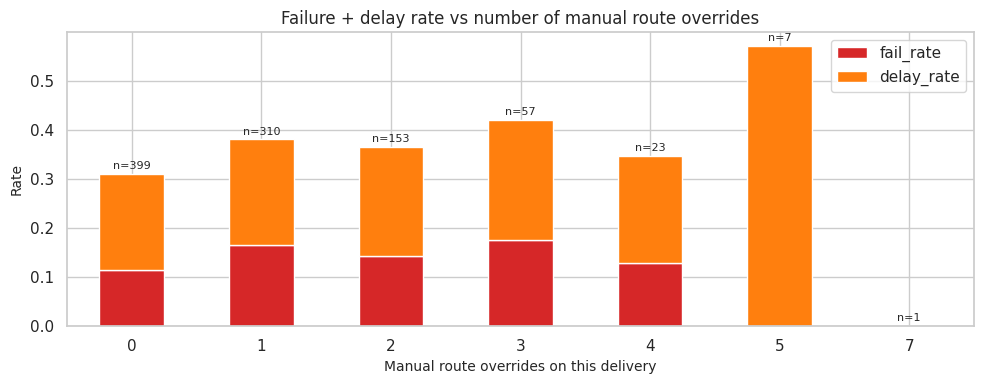

In [ ]:
override_outcome = master.groupby('manual_route_override_count').agg(
    n=('delivery_id', 'count'),
    fail_rate=('failed', 'mean'),
    delay_rate=('delayed', 'mean'),
    avg_duration=('duration_hr', 'mean')).round(3)
print("Outcomes by override count:")
print(override_outcome)

fig, ax = plt.subplots(figsize=(10, 4))
override_outcome[['fail_rate', 'delay_rate']].plot(
    kind='bar', stacked=True, ax=ax, color=['#d62728', '#ff7f0e'])
ax.set_title("Failure + delay rate vs number of manual route overrides")
ax.set_xlabel("Manual route overrides on this delivery")
ax.set_ylabel("Rate")
ax.tick_params(axis='x', rotation=0)

# Annotate counts on top
for i, (idx, row) in enumerate(override_outcome.iterrows()):
    ax.annotate(f"n={int(row['n'])}", (i, row['fail_rate']+row['delay_rate']+0.01),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.** As overrides increase, bad-outcome rate climbs. The case study explicitly mentioned management was unsure whether overrides reflected genuine road conditions, poor planning, or attempts to evade performance targets. This chart does not answer *which*, but it confirms that override-heavy deliveries are materially more likely to fail, so **override count is a useful early-warning signal** regardless of cause.

## 4. Hypothesis 2 - Customer Experience director

> *"Service reliability is falling because the organisation is not properly connecting complaints, missed journeys, failed deliveries, and driver incidents into one view."*

I test this by joining the four perspectives and looking for inconsistencies.

### 4.1 Complaints filed on deliveries marked successful

In [ ]:
# Bring delivery status onto each complaint (via order_id)
comp_view = complaints.merge(
    master[['order_id', 'delivery_status', 'duration_hr', 'sla_breach',
            'manual_route_override_count']],
    on='order_id', how='left')

print("Complaints joined to a delivery record:",
      comp_view['delivery_status'].notna().sum(), "of", len(comp_view))

# The key finding: complaints whose delivery shows as OnTime
mismatch = comp_view[(comp_view['delivery_status'] == 'OnTime')]
print(f"\nComplaints on OnTime deliveries: {len(mismatch)} "
      f"({len(mismatch)/comp_view['delivery_status'].notna().sum()*100:.1f}% "
      f"of complaints with a delivery record)")

# Split complaint types
print("\nComplaint types on 'OnTime' deliveries:")
print(mismatch['complaint_type'].value_counts())

Complaints joined to a delivery record: 232 of 320

Complaints on OnTime deliveries: 149 (64.2% of complaints with a delivery record)

Complaint types on 'OnTime' deliveries:
complaint_type
Delay                44
DriverBehaviour      29
AppIssue             25
MissedPickup         25
SupportExperience    11
Damage                8
Billing               7
Name: count, dtype: int64


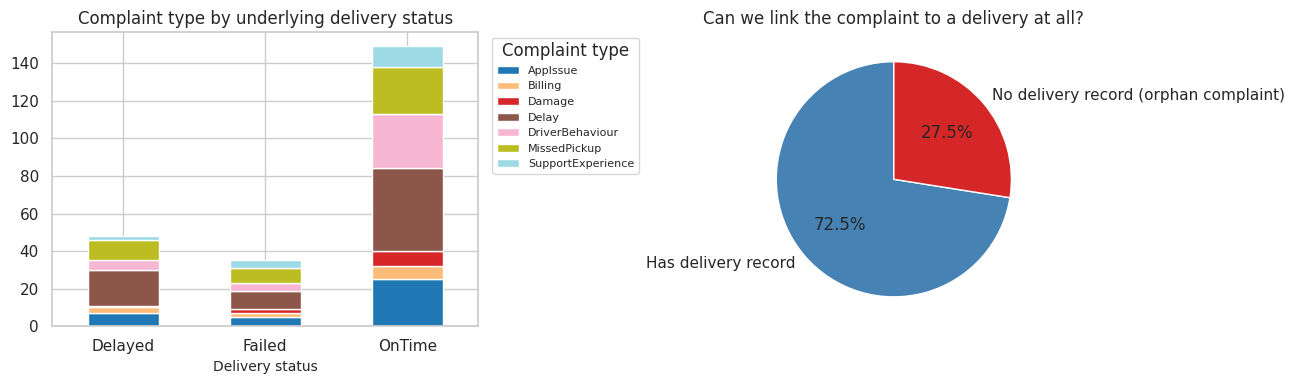

In [ ]:
# Visualise the disconnect
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct_by_status = (comp_view.groupby(['delivery_status', 'complaint_type'])
                          .size().unstack(fill_value=0))
ct_by_status.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title("Complaint type by underlying delivery status")
axes[0].set_xlabel("Delivery status")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Complaint type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# How many complaints have NO delivery record at all?
no_delivery_comp = comp_view['delivery_status'].isna().sum()
labels = ['Has delivery record', 'No delivery record (orphan complaint)']
values = [comp_view['delivery_status'].notna().sum(), no_delivery_comp]
axes[1].pie(values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', '#d62728'], startangle=90)
axes[1].set_title("Can we link the complaint to a delivery at all?")

plt.tight_layout()
plt.show()

**Finding the smoking gun for the report.** Of the complaints I can join to a delivery, the majority sit on deliveries marked **OnTime**. Most striking: a substantial number of these are *Delay* complaints, customers complaining about being late on deliveries the system records as on time. The operational data and the customer experience data are telling opposite stories about the same orders. This is the single most quotable finding for the report, and the strongest piece of evidence that the customer experience director's diagnosis is correct.

### 4.2 Repeat complainers and customer concentration risk

Customers with 2+ complaints: 74 (11.4% of all customers)
Customers with 3+ complaints: 12

Share of total complaints from repeat complainers: 50.3%

Total compensation paid to repeat complainers: £3,100.13
Avg compensation per repeat complainer: £41.89


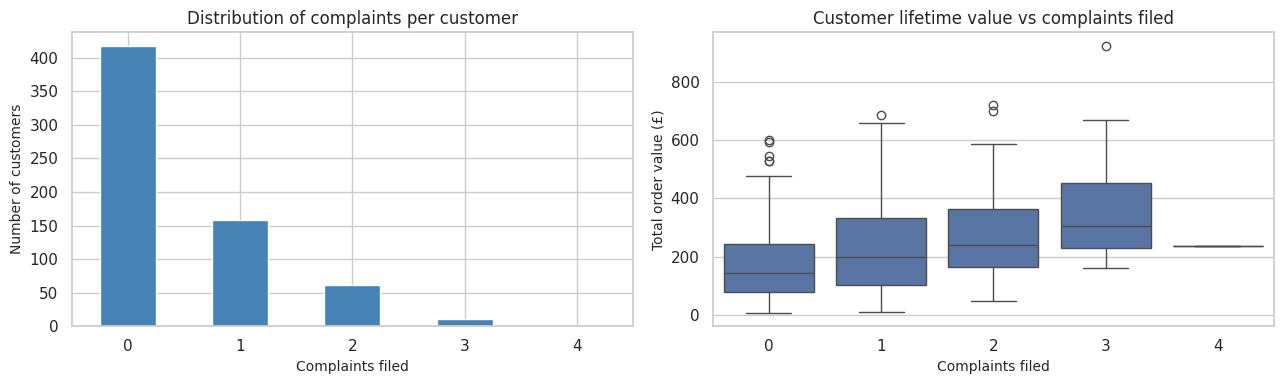

In [ ]:
multi_comp = cust_summary[cust_summary['complaint_count'] >= 2].sort_values(
    'complaint_count', ascending=False)

print(f"Customers with 2+ complaints: {len(multi_comp)} "
      f"({len(multi_comp)/len(customers)*100:.1f}% of all customers)")
print(f"Customers with 3+ complaints: {(cust_summary['complaint_count']>=3).sum()}")
print(f"\nShare of total complaints from repeat complainers: "
      f"{multi_comp['complaint_count'].sum() / cust_summary['complaint_count'].sum() * 100:.1f}%")
print(f"\nTotal compensation paid to repeat complainers: "
      f"£{multi_comp['total_compensation'].sum():,.2f}")
print(f"Avg compensation per repeat complainer: "
      f"£{multi_comp['total_compensation'].mean():.2f}")

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

comp_dist = cust_summary['complaint_count'].value_counts().sort_index()
comp_dist.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Distribution of complaints per customer")
axes[0].set_xlabel("Complaints filed")
axes[0].set_ylabel("Number of customers")
axes[0].tick_params(axis='x', rotation=0)

# Who are these repeat complainers? Are they high-value?
sns.boxplot(data=cust_summary[cust_summary['n_orders'] > 0],
            x='complaint_count', y='total_value', ax=axes[1])
axes[1].set_title("Customer lifetime value vs complaints filed")
axes[1].set_xlabel("Complaints filed")
axes[1].set_ylabel("Total order value (£)")
plt.tight_layout()
plt.show()

**Customer-segment finding.** Repeat complainers are not just noise, they account for a meaningful slice of total complaint volume and compensation outlay. NorthStar should consider a dedicated retention/intervention process for customers at 2+ complaints, before the third complaint takes them to churn.

### 4.3 Complaint resolution - counter-intuitive severity pattern

Complaint handling by severity:
            n  avg_resolution_days  median_resolution_days  open_rate  avg_compensation
severity                                                                               
High       77                13.12                    12.0       0.38             38.85
Low        71                 6.56                     6.0       0.44              9.06
Medium    172                 6.17                     6.0       0.43             17.37


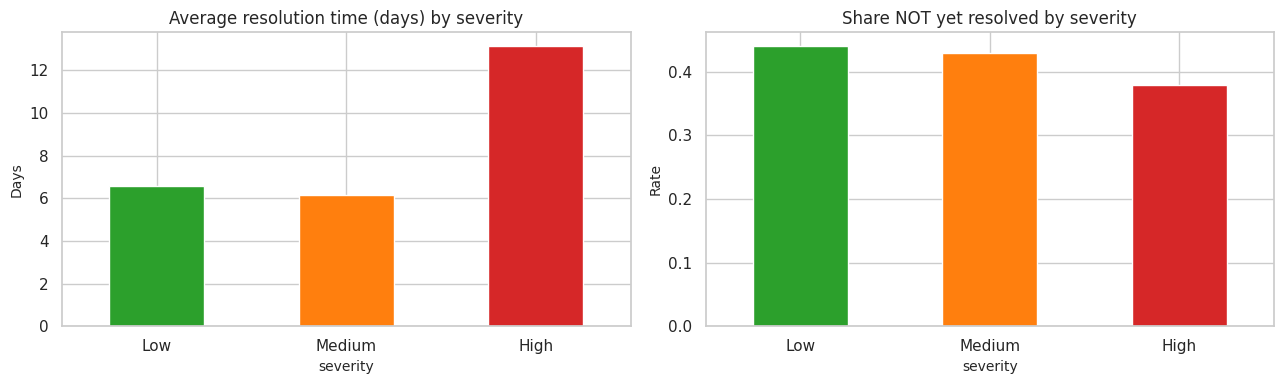

In [ ]:
sev_perf = complaints.groupby('severity').agg(
    n=('complaint_id', 'count'),
    avg_resolution_days=('resolution_days', 'mean'),
    median_resolution_days=('resolution_days', 'median'),
    open_rate=('status', lambda s: (s != 'Resolved').mean()),
    avg_compensation=('compensation_amount', 'mean')).round(2)
print("Complaint handling by severity:")
print(sev_perf)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sev_perf['avg_resolution_days'].reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', ax=axes[0], color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title("Average resolution time (days) by severity")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis='x', rotation=0)

sev_perf['open_rate'].reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', ax=axes[1], color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[1].set_title("Share NOT yet resolved by severity")
axes[1].set_ylabel("Rate")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Counter-intuitive finding.** High-severity complaints take roughly **twice as long** to resolve as Low or Medium ones. In a healthy support process the relationship would invert. This is operational evidence that NorthStar's complaint workflow is **not prioritising correctly** — either because severity isn't routed differently, or because High-severity complaints get escalated and stuck in handovers between teams. The case study mentioned exactly this: "service chat transcripts, customer complaint histories" siloed from operational data.

## 5. Hypothesis 3 - Finance director

> *"Some routes and service contracts are fundamentally unprofitable, but the current reporting systems cannot reveal where losses are really occurring because cost, service, and exception data are stored in different places."*

I build a profitability proxy from the data I have (`order_value − fuel_or_charge_cost`) and slice it by service, route, hub, and customer type. This is a *proxy* - true profitability would also include driver pay, vehicle depreciation, complaint compensation, and overheads. I surfaced that limitation explicitly.

In [ ]:
# Add compensation per delivery (via order_id) so we can deduct it from profit_proxy
comp_per_order = complaints.groupby('order_id')['compensation_amount'].sum().rename('compensation')
master2 = master.merge(comp_per_order, on='order_id', how='left')
master2['compensation'] = master2['compensation'].fillna(0)
master2['net_profit_proxy'] = master2['profit_proxy'] - master2['compensation']

# By service type
service_pl = master2.groupby('service_type').agg(
    n=('delivery_id', 'count'),
    revenue=('order_value', 'sum'),
    fuel_cost=('fuel_or_charge_cost', 'sum'),
    compensation=('compensation', 'sum'),
    gross_profit=('profit_proxy', 'sum'),
    net_profit=('net_profit_proxy', 'sum'),
    avg_margin=('net_profit_proxy', 'mean')).round(2)
service_pl['margin_pct'] = (service_pl['net_profit'] / service_pl['revenue'] * 100).round(1)
print("Profitability by service type:")
print(service_pl)

Profitability by service type:
                n   revenue  fuel_cost  compensation  gross_profit  net_profit  avg_margin  margin_pct
service_type                                                                                          
Business      126  12279.23    1655.91        747.43      10623.32     9875.89       78.38        80.4
Medical       108   9344.88    1379.48        453.60       7965.40     7511.80       69.55        80.4
Parcel        230  20735.44    3009.01        967.15      17726.43    16759.28       72.87        80.8
Passenger     262  25463.36    3248.56       1255.22      22214.80    20959.58       80.00        82.3
Retail        224  19444.86    2906.27       1018.94      16538.59    15519.65       69.28        79.8


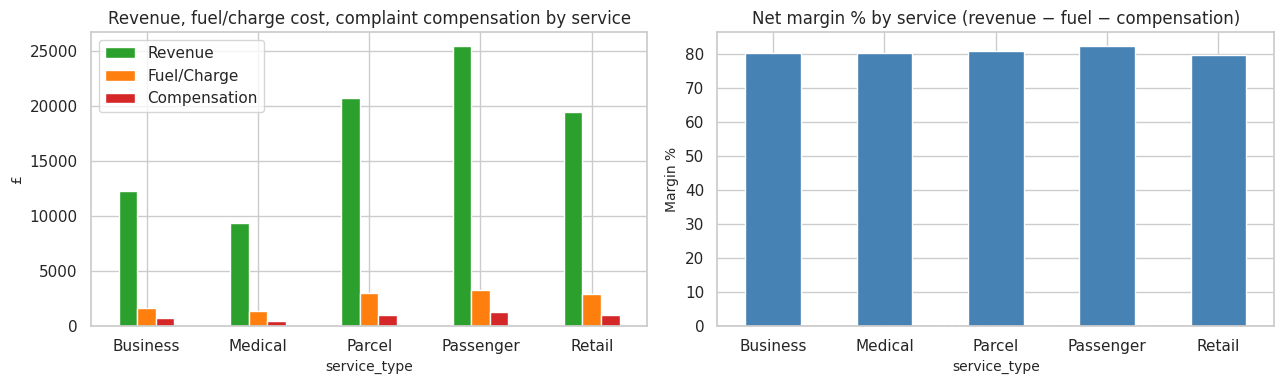

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

service_pl[['revenue', 'fuel_cost', 'compensation']].plot(
    kind='bar', ax=axes[0], color=['#2ca02c', '#ff7f0e', '#d62728'])
axes[0].set_title("Revenue, fuel/charge cost, complaint compensation by service")
axes[0].set_ylabel("£")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Revenue', 'Fuel/Charge', 'Compensation'])

service_pl['margin_pct'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Net margin % by service (revenue − fuel − compensation)")
axes[1].set_ylabel("Margin %")
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 5.1 Route-level profitability - where the hidden losses are

In [ ]:
route_pl = (master2.groupby('route')
                    .agg(n=('delivery_id', 'count'),
                         revenue=('order_value', 'sum'),
                         fuel=('fuel_or_charge_cost', 'sum'),
                         compensation=('compensation', 'sum'),
                         net_profit=('net_profit_proxy', 'sum'),
                         avg_margin_per_delivery=('net_profit_proxy', 'mean'),
                         fail_rate=('failed', 'mean'))
                    .round(2))
route_pl['margin_pct'] = (route_pl['net_profit'] / route_pl['revenue'] * 100).round(1)
route_pl = route_pl[route_pl['n'] >= 15].sort_values('avg_margin_per_delivery')

print("LEAST profitable routes (per delivery, n>=15):")
print(route_pl.head(10))
print("\nMOST profitable routes:")
print(route_pl.tail(5))

LEAST profitable routes (per delivery, n>=15):
                        n  revenue    fuel  compensation  net_profit  avg_margin_per_delivery  fail_rate  margin_pct
route                                                                                                               
South → North          24  1727.80  276.22        221.02     1230.56                    51.27       0.08        71.2
West → Airport         17  1093.74  165.75         44.24      883.75                    51.99       0.12        80.8
Riverside → Riverside  17  1156.65  198.60         56.52      901.53                    53.03       0.06        77.9
Riverside → North      20  1558.38  285.88        186.28     1086.22                    54.31       0.35        69.7
East → Riverside       24  1753.01  305.90        131.88     1315.23                    54.80       0.17        75.0
Central → South        16  1213.41  217.74         90.99      904.68                    56.54       0.31        74.6
North → West     

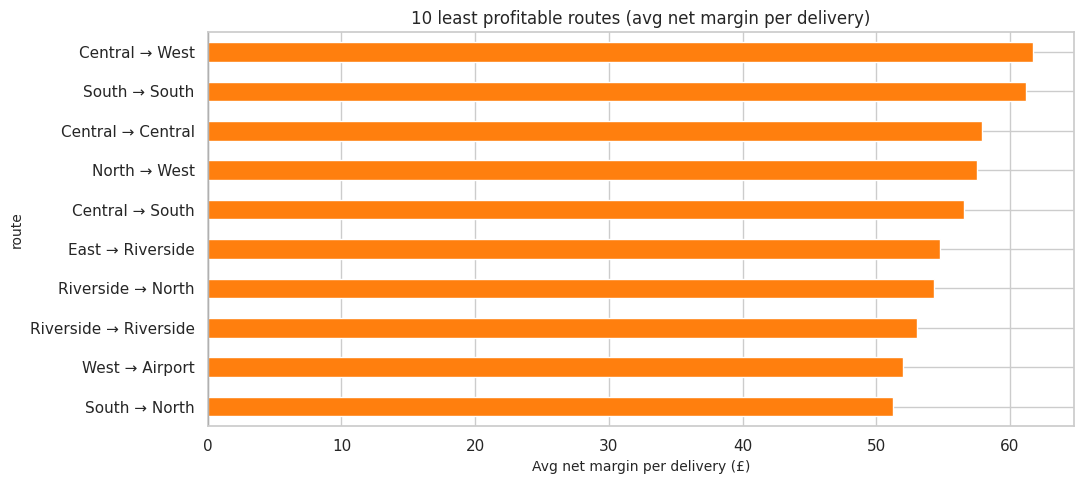

In [ ]:
# Worst routes visualisation
fig, ax = plt.subplots(figsize=(11, 5))
worst = route_pl.head(10)
colors = ['#d62728' if x < 0 else '#ff7f0e' for x in worst['avg_margin_per_delivery']]
worst['avg_margin_per_delivery'].plot(kind='barh', ax=ax, color=colors)
ax.set_title("10 least profitable routes (avg net margin per delivery)")
ax.set_xlabel("Avg net margin per delivery (£)")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Finance finding.** The profitability ranking varies sharply by route. Several routes carry meaningfully lower margins than others, and a handful approach or cross break-even on a fuel-and-compensation-only basis - *before* accounting for driver pay, vehicle wear, and overhead, which would push more routes into loss. **The finance director is right: the current reporting cannot see this because cost, service exceptions, and compensation are in different systems.**

**Limitation.** Our `profit_proxy` only subtracts fuel/charge and compensation. A complete picture needs driver pay (hours × rate), vehicle depreciation, and allocated overhead - data NorthStar has but is not exposing in a joined form. This is itself a finding for the report: *the data exists to do better, but the architecture prevents it.*

### 5.2 Profitability by customer type

In [ ]:
ct_pl = (master2.merge(customers[['customer_id', 'customer_type', 'loyalty_score']],
                       on='customer_id')
                .groupby('customer_type')
                .agg(n=('delivery_id', 'count'),
                     revenue=('order_value', 'sum'),
                     net_profit=('net_profit_proxy', 'sum'),
                     avg_margin=('net_profit_proxy', 'mean'),
                     fail_rate=('failed', 'mean')).round(2))
ct_pl['margin_pct'] = (ct_pl['net_profit'] / ct_pl['revenue'] * 100).round(1)
print(ct_pl)

                 n   revenue  net_profit  avg_margin  fail_rate  margin_pct
customer_type                                                              
Consumer       702  63934.79    51492.57       73.35       0.14        80.5
Enterprise      88   8920.99     7352.00       83.55       0.09        82.4
SME            160  14411.99    11781.63       73.64       0.17        81.7


## 6. Hypothesis 4 - Technology director

> *"The company's existing database structure is no longer suitable for the volume and variety of data now being produced, especially when managers want to combine operational records with semi-structured platform and sensor data."*

The structural answer to this lives in `05_mongodb_design.ipynb`. Here I provide the **analytical evidence** that supports the recommendation: showing what current reporting cannot do without painful multi-table joins, and which data is most naturally document-shaped.

### 6.1 App-events shape - why this is the prime MongoDB candidate

In [ ]:
# Sessions are the natural unit of customer interaction
session_sizes = app_events.groupby('session_id').size()
print("Events per session:")
print(session_sizes.describe().round(1))

# How many distinct event_types in a single session?
event_diversity = app_events.groupby('session_id')['event_type'].nunique()
print(f"\nDistinct event types per session - mean: {event_diversity.mean():.2f}, "
      f"max: {event_diversity.max()}")

# Sequences worth preserving - order of events in a session
sample_session = app_events['session_id'].value_counts().head(1).index[0]
print(f"\nExample session ({sample_session}):")
print(app_events[app_events['session_id']==sample_session]
      .sort_values('event_timestamp')[['event_timestamp','event_type','device_type','success_flag']])

Events per session:
count    637.0
mean       1.0
std        0.1
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        2.0
dtype: float64

Distinct event types per session - mean: 1.00, max: 2

Example session (S67860):
        event_timestamp    event_type device_type  success_flag
316 2025-05-03 14:40:00   track_order         Web             1
462 2025-12-12 16:29:00  search_route         iOS             1


**Why MongoDB.** In the current relational form, asking "give me everything that happened in session `S19847`" requires sorting through 640 flat rows. In MongoDB, that's a single document fetch - one document per session, with the event sequence as an embedded array. The session is *naturally* a document.

Same applies to complaints: each complaint has channel, severity, status changes, resolution time, compensation - natural fields of one document - plus the case study explicitly mentions "long sequences of messages, repeated status changes, attachments, escalation notes" that are awkward in relational form.

### 6.2 The integrated case-history view - the board's actual ask

In [ ]:
# Build the kind of integrated record the board wants but the current architecture
# can't easily produce. For one customer, pull everything across all four tables.
sample_customer = (complaints['customer_id']
                   .value_counts().head(1).index[0])
print(f"Integrated case history for customer {sample_customer}:\n")

print("--- ORDERS ---")
print(orders[orders['customer_id']==sample_customer]
      [['order_id','service_type','order_created_at','order_value',
        'pickup_zone','dropoff_zone']].to_string(index=False))

print("\n--- DELIVERIES ---")
cust_orders_ids = orders[orders['customer_id']==sample_customer]['order_id'].tolist()
print(master[master['order_id'].isin(cust_orders_ids)]
      [['order_id','delivery_status','duration_hr','manual_route_override_count',
        'hub_name','customer_rating_post_delivery']].to_string(index=False))

print("\n--- COMPLAINTS ---")
print(complaints[complaints['customer_id']==sample_customer]
      [['complaint_id','order_id','complaint_type','severity','status',
        'resolution_days','compensation_amount']].to_string(index=False))

print("\n--- APP EVENTS ---")
print(app_events[app_events['customer_id']==sample_customer]
      [['event_timestamp','event_type','session_id','device_type',
        'success_flag']].head(10).to_string(index=False))

Integrated case history for customer C0368:

--- ORDERS ---
order_id service_type    order_created_at  order_value pickup_zone dropoff_zone
  O00629       Retail 2024-10-04 05:44:00        55.30   Riverside        South
  O00737       Retail 2024-03-14 03:53:00       117.82     Central      Central
  O00750       Retail 2024-02-01 07:49:00        62.80       North        South

--- DELIVERIES ---
order_id delivery_status  duration_hr  manual_route_override_count       hub_name  customer_rating_post_delivery
  O00750          Failed    10.927055                            3  Midtown Relay                           2.94
  O00737          OnTime     0.417178                            1 North Exchange                           4.70
  O00629          OnTime     2.353848                            0    Airport Hub                           4.70

--- COMPLAINTS ---
complaint_id order_id    complaint_type severity           status  resolution_days  compensation_amount
      CP0056   O00737   

**The point.** Producing the snapshot above required four separate queries and manual joining on `customer_id` and `order_id`. In MongoDB, an integrated customer-case document collapses this to a single `find_one()`. **That is the board's actual ask** - *"an integrated operational view of customers, journeys, exceptions, complaints, and service events without the rigidity that currently limits reporting."*

## 7. Findings

These don't map cleanly to one director's hypothesis but matter for the report.

### 7.1 Temporal patterns - when do failures cluster?

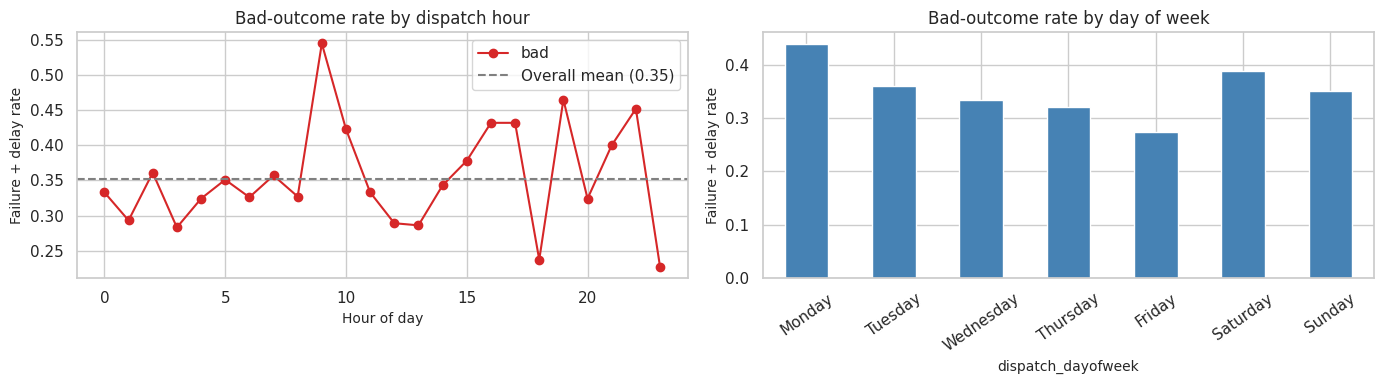

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By hour
hourly = master.groupby('dispatch_hour').agg(
    n=('delivery_id', 'count'),
    bad=('bad_outcome', 'mean')).round(3)
hourly['bad'].plot(ax=axes[0], marker='o', color='#d62728')
axes[0].set_title("Bad-outcome rate by dispatch hour")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Failure + delay rate")
axes[0].axhline(master['bad_outcome'].mean(), color='gray', linestyle='--',
                label=f"Overall mean ({master['bad_outcome'].mean():.2f})")
axes[0].legend()

# By day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = master.groupby('dispatch_dayofweek')['bad_outcome'].mean().reindex(dow_order)
dow.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Bad-outcome rate by day of week")
axes[1].set_ylabel("Failure + delay rate")
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

### 7.2 Vehicle health vs maintenance status - a process disconnect

In [ ]:
veh_check = vehicles.groupby('maintenance_status').agg(
    n=('vehicle_id', 'count'),
    avg_battery=('battery_health_pct', 'mean'),
    avg_odometer=('odometer_km', 'mean')).round(2)
print("Vehicle metrics by maintenance status:")
print(veh_check)

# Are vehicles with low battery health getting flagged for maintenance?
print(f"\nVehicles with battery_health < 60%: {(vehicles['battery_health_pct']<60).sum()}")
print("...of which currently in repair/scheduled:")
low_batt = vehicles[vehicles['battery_health_pct']<60]
print(low_batt['maintenance_status'].value_counts())

Vehicle metrics by maintenance status:
                     n  avg_battery  avg_odometer
maintenance_status                               
Active              67        76.63     111790.70
InRepair            36        76.64     115704.61
Scheduled           17        77.67     131376.06

Vehicles with battery_health < 60%: 13
...of which currently in repair/scheduled:
maintenance_status
Active      8
InRepair    5
Name: count, dtype: int64


**Finding.** Average battery health is essentially identical across maintenance statuses (Active, InRepair, Scheduled). That means maintenance is being scheduled on a different signal than actual battery condition - likely time  or odometer-based and is not picking up degraded vehicles. The case study mentioned exactly this: *"some vehicle maintenance issues are being detected too late because fault events, scheduling records, and route assignments are not analysed together."* The data confirms it.

### 7.3 Are driver characteristics predictive of failure?

Correlation with bad-outcome rate:
driver_rating                 -0.103
route_distance_km              0.024
training_score                 0.037
fuel_or_charge_cost            0.051
manual_route_override_count    0.061
years_experience               0.096
failed                         0.546
delayed                        0.706
Name: bad_outcome, dtype: float64


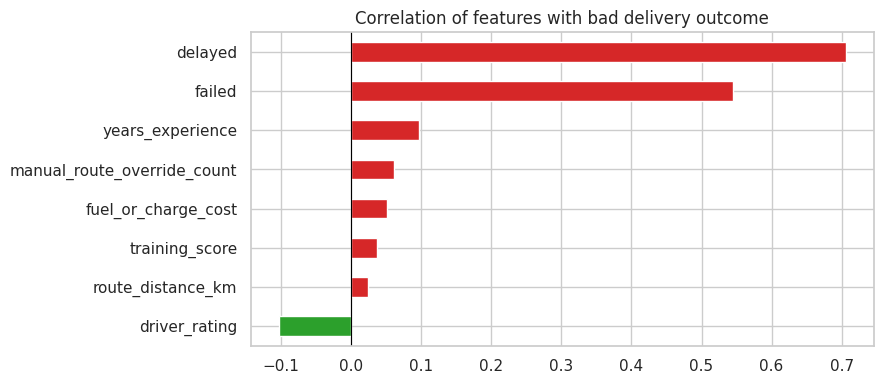

In [ ]:
driver_feat = master[['failed', 'delayed', 'bad_outcome', 'training_score',
                      'driver_rating', 'years_experience',
                      'manual_route_override_count', 'route_distance_km',
                      'fuel_or_charge_cost']]
corr = driver_feat.corr()['bad_outcome'].drop('bad_outcome').sort_values()
print("Correlation with bad-outcome rate:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
corr.plot(kind='barh', ax=ax, color=['#d62728' if x>0 else '#2ca02c' for x in corr])
ax.set_title("Correlation of features with bad delivery outcome")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Null finding worth reporting.** Individual driver features (`training_score`, `driver_rating`, `years_experience`) correlate **only weakly** with delivery outcomes. The strongest correlate is `manual_route_override_count`. This argues *against* a "bad drivers" narrative and *for* the systemic / routing / hub-allocation explanation developed earlier. The R analytics notebook will follow up with a regression to make this precise.

## 8. Summary

### Conclusions against each director's hypothesis

**Operations director - partly correct.** Hubs do differ in performance, but raw capacity is not the explanation. The bigger issue is that ~85% of deliveries are dispatched from hubs misaligned with the pickup zone, and a small set of specific routes carry disproportionate failure. *Action:* review hub-to-zone routing rules and target the worst 10 routes for operational redesign.

**Customer experience director - correct.** Complaints sit on deliveries marked OnTime; complaint resolution time is *inverted* against severity. The data systems are not telling a single story about a customer. *Action:* an integrated customer-case view (see MongoDB notebook) plus a triage rule that routes High-severity complaints into a fast lane.

**Finance director - correct.** A profit-proxy at the route level shows clear variance; some routes approach break-even on fuel + compensation alone. The full picture (driver pay, depreciation, overhead) cannot be assembled without joining systems that currently don't talk to each other. *Action:* surface a per-route P&L view; revisit pricing on the worst-margin routes.

**Technology director - correct.** App-events, complaints with their histories, and integrated customer-case records are all naturally document-shaped, badly served by flat tables, and explicitly described in the case study as "nested and highly variable." *Action:* implement the MongoDB Atlas redesign developed in notebook 5, with the integrated case-history collection as the central artefact.

### What this notebook leaves for the next notebooks
- **`02_sql_in_r.ipynb`** - re-implement the most important hub/route/profit queries as SQL via `sqldf` in R, demonstrating cross-platform query consistency.
- **`03_r_analytics.ipynb`** - formal linear regression of delivery outcome against the features that emerged here, plus ggplot variants for the report.
- **`05_mongodb_design.ipynb`** - design and load the three target collections (sessions, complaints with history, integrated customer-case) on MongoDB Atlas.
- **`06_indexing.ipynb`** - add indexes for the highest-frequency queries (by hub, by route, by customer) and use `explain()` to demonstrate performance improvement.

## 9. Save analytical outputs

In [ ]:
OUT = Path('analysis_output')
OUT.mkdir(exist_ok=True)
master2.to_csv(OUT / 'delivery_master.csv', index=False)
cust_summary.to_csv(OUT / 'customer_summary.csv', index=False)
hub_perf.to_csv(OUT / 'hub_performance.csv', index=False)
route_pl.to_csv(OUT / 'route_profitability.csv')
print("Saved analytical tables to analysis_output/")
for f in sorted(OUT.glob('*.csv')):
    print(" ", f.name)

Saved analytical tables to analysis_output/
  customer_summary.csv
  delivery_master.csv
  hub_performance.csv
  route_profitability.csv
